In [1]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")
from skew_correction import full_correction

import numpy as np
import os 
import sys
import astropy.units as u
from astropy.io import fits
from plotting_modules import doppler_plot, amplitude_plot
import matplotlib.pyplot as plt

In [2]:
spice_file = "/cluster/home/zhuyin/Solar/SPICE_psf_202210/src/solo_L2_spice-n-ras_20221024T231535_V22_150995398-000.fits"

with fits.open(spice_file) as hdul:
    # hdul.info()
    spice_NeVIII_data = hdul[3].data[0].copy()
    spice_NeVIII_header = hdul[3].header.copy()
spice_NeVIII_data = spice_NeVIII_data.T
# spice_NeVIII_header["NAXIS1"] = 60
# spice_NeVIII_header["NAXIS2"] = 240
# spice_NeVIII_data = spice_NeVIII_data[30:90,240:480,:]

In [3]:
spice_NeVIII_data.shape

(192, 832, 50)

In [4]:
best_skew_x, best_skew_y = 1.667, -1.667

best_correction_results = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x, best_skew_y,
                          nthreads=12, linelist={'Ne VIII 770':770.4})

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [5]:
best_correction_results.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [6]:
best_correction_results['xlshift']

1.667

[Text(0.5, 1.0, 'Doppler; best xshift, yshift=1.667,-1.667')]

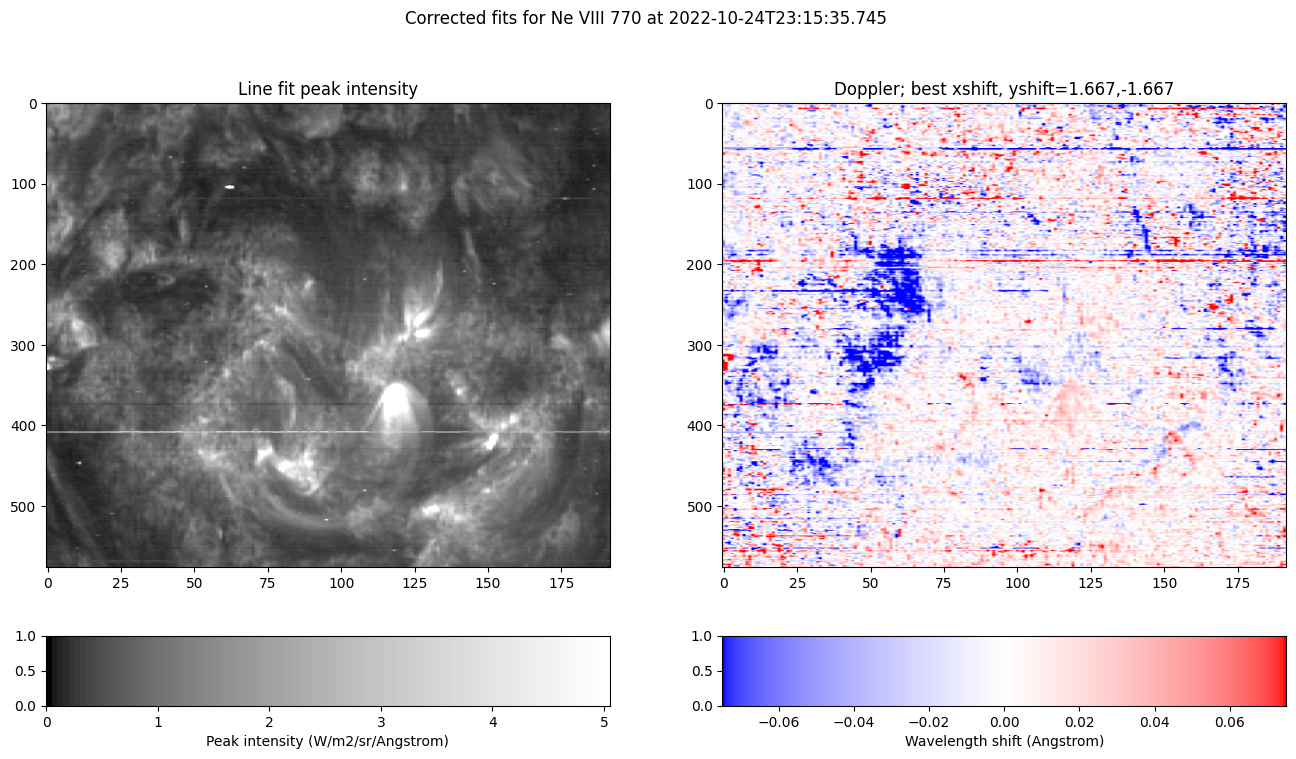

In [7]:
plt_linefits = best_correction_results['linefits']
ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
line_name = list(plt_linefits[0].keys())[0]
date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

fig=plt.figure(figsize=[16,8])
gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

plt.suptitle('Corrected fits for '+line_name+' at '+date)
amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax,)
doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
axes[1].set(title='Doppler; best xshift, yshift='+str(best_skew_x)+','+str(best_skew_y))

In [8]:
plt_linefits[0][0].keys()

dict_keys(['amplitudes', 'centers', 'sigmas'])

In [9]:
plt_linefits[0][0]['amplitudes'].data.shape

(192, 832, 1, 1)

In [10]:
np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221024/spice_20221024T231535_NeVIII_skew_fit_params.npz",
        **best_correction_results
        )